
# New natural and synthetic must data loading

This notebook validates the new primary datasets:

- `fermentation_model/data/mosto_natural_xthiol.xlsx`
- `fermentation_model/data/mosto_sintetico_vl3.xlsx`

The previous `Calibration_data_vl3.xlsx` file is intentionally not used here. The notebook focuses on reproducible ingestion, unit conversion, operational-input visualization, density-based sugar estimation, and a baseline simulation with the current Zenteno-style fermentation model.

The baseline simulation is not a final calibration. It uses the current reduced parameter set only to verify that the new data can be converted into model-compatible inputs.



## Data model and unit conventions

The relevant measured variables are standardized as follows.

- Process time: `time_h`, in h.
- Temperature setpoint: `temperature_c`, in deg C.
- Density: `density`, kept in the native density scale reported by the workbook.
- Viable biomass: `X_viable_mcells_ml`, in million cells/mL.
- Total biomass: `X_total_mcells_ml`, from Oculyze total concentration.
- Dead biomass: `X_dead_mcells_ml = max(X_total_mcells_ml - X_viable_mcells_ml, 0)`.
- Biomass conversion: 30 pg/cell, therefore 1 million cells/mL = 0.003 kg/m3.
- Glucose, fructose, glycerol: g/L, numerically equal to kg/m3.
- YAN and nutrient pulses: mg/L N, converted to kg/m3 using 1 mg/L = 0.001 kg/m3.
- Ethanol: % v/v, converted as

$$
E_{g/L} = E_{\%v/v}\,10\,\rho_{EtOH}, \qquad \rho_{EtOH}=0.78924\;g/mL.
$$

For density-based sugar estimation, the default linear proxy is fitted as

$$
S_{G+F} = a + b\,\rho,
$$

where $S_{G+F}$ is the measured total sugar from glucose plus fructose. The Y15 total sugar column is retained as an independent/check signal when available.


In [1]:

from pathlib import Path
import contextlib
import io
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "fermentation_model").exists():
    REPO_ROOT = REPO_ROOT.parent
FERMENTATION_DIR = REPO_ROOT / "fermentation_model"
RESULTS_DIR = FERMENTATION_DIR / "results" / "new_must_data_loading"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if str(FERMENTATION_DIR) not in sys.path:
    sys.path.insert(0, str(FERMENTATION_DIR))

import new_must_data_loader as loader

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})


In [2]:

unit_conventions = pd.Series(
    {
        "ethanol_density_g_ml": loader.ETHANOL_DENSITY_G_ML,
        "ethanol_g_l_per_percent_vv": loader.ETHANOL_G_L_PER_PERCENT_VV,
        "cell_mass_g_per_cell": loader.CELL_MASS_G_PER_CELL,
        "million_cells_ml_to_kg_m3": loader.MILLION_CELLS_ML_TO_KG_M3,
        "mg_l_to_kg_m3": loader.MG_L_TO_KG_M3,
    },
    name="value",
)
display(unit_conventions)


ethanol_density_g_ml          7.892400e-01
ethanol_g_l_per_percent_vv    7.892400e+00
cell_mass_g_per_cell          3.000000e-11
million_cells_ml_to_kg_m3     3.000000e-02
mg_l_to_kg_m3                 1.000000e-03
Name: value, dtype: float64


## Load and normalize all fermentation sheets

The loader reads only fermentation sheets: `LAB...` sheets from the natural must workbook and `MS...` sheets from the synthetic must workbook. Summary/dictionary/event sheets are excluded to avoid duplicated records.


In [3]:

data = loader.load_new_must_data()
summary = loader.batch_summary(data)

data.to_csv(RESULTS_DIR / "new_must_normalized_long.csv", index=False)
summary.to_csv(RESULTS_DIR / "new_must_batch_summary.csv", index=False)

print(f"Normalized rows: {len(data)}")
print(f"Batches by medium: {data.groupby('medium')['batch'].nunique().to_dict()}")
display(summary)


Normalized rows: 208
Batches by medium: {'natural': 9, 'synthetic': 10}


,medium,batch,n_rows,t_min_h,t_max_h,temperature_initial_c,temperature_min_c,temperature_max_c,G_initial_g_l,F_initial_g_l,S_initial_g_l,YAN_initial_mg_l,E_final_g_l,X_viable_initial_kg_m3,X_dead_initial_kg_m3,n_density,n_gf,n_y15,n_total_cells,n_ethanol,n_pulses,total_N_pulse_mg_l
0,natural,LAB004,14,0.0,163.0,18.0,18.0,21.0,75.04,70.81,145.85,230.76,82.396656,0.39390,0.00930,13,13,13,12,5,1,80.0
1,natural,LAB005,14,0.0,163.0,18.0,18.0,21.0,77.71,87.95,165.66,227.30,80.660328,0.49320,0.01590,13,13,13,12,5,1,80.0
2,natural,LAB006,16,0.0,211.0,16.0,16.0,18.0,81.63,75.81,157.44,229.12,82.712352,0.09900,0.02760,15,15,15,14,5,1,80.0
3,natural,LAB007,14,0.0,160.0,21.0,18.0,21.0,77.52,74.55,152.07,239.04,81.291720,0.29160,0.00090,12,13,13,13,6,1,80.0
4,natural,LAB008,14,0.0,160.0,18.0,18.0,21.0,76.21,74.89,151.10,239.22,81.923112,0.25350,0.00330,12,13,13,13,6,1,80.0
5,natural,LAB009,13,0.0,160.0,18.0,18.0,21.0,75.75,76.68,152.43,237.40,80.897100,0.36030,0.00090,11,12,12,12,5,1,80.0
6,natural,LAB010,10,0.0,187.0,15.0,15.0,15.0,78.49,77.05,155.54,225.70,80.028936,0.96090,0.11280,9,4,4,9,4,1,80.0
7,natural,LAB011,8,0.0,163.0,18.0,15.0,21.0,75.61,76.67,152.28,220.24,81.133872,1.06560,0.03810,7,4,4,7,4,1,80.0
8,natural,LAB012,9,0.0,163.0,15.0,15.0,21.0,75.00,79.88,154.88,222.06,81.054948,0.85140,0.12090,8,4,4,8,4,1,80.0
9,synthetic,MS007,10,0.0,213.0,15.0,15.0,15.0,125.34,120.52,245.86,224.00,79.239696,0.33300,0.11700,9,9,9,9,4,1,100.0


In [4]:

critical_columns = [
    "time_h", "temperature_c", "density", "X_viable_mcells_ml", "X_total_mcells_ml",
    "X_dead_mcells_ml", "G_g_l", "F_g_l", "S_GF_g_l", "S_Y15_g_l",
    "YAN_mg_l", "N_pulse_mg_l", "glycerol_g_l", "ethanol_percent_vv", "E_g_l",
]
completeness = (
    data.groupby("medium")[critical_columns]
    .agg(lambda s: int(s.notna().sum()))
    .T
)
completeness["total"] = data[critical_columns].notna().sum().astype(int)
display(completeness)

inferred_dead = data[data["X_dead_inferred"]][["medium", "batch", "time_h", "X_total_mcells_ml", "X_viable_mcells_ml", "X_dead_mcells_ml"]]
print(f"Rows with inferred dead biomass because viable biomass was missing: {len(inferred_dead)}")
display(inferred_dead.head(20))


medium,natural,synthetic,total
time_h,112,96,208
temperature_c,108,86,194
density,100,86,186
X_viable_mcells_ml,100,76,176
X_total_mcells_ml,100,86,186
X_dead_mcells_ml,100,86,186
G_g_l,91,86,177
F_g_l,91,86,177
S_GF_g_l,91,86,177
S_Y15_g_l,91,86,177


Rows with inferred dead biomass because viable biomass was missing: 10


,medium,batch,time_h,X_total_mcells_ml,X_viable_mcells_ml,X_dead_mcells_ml
112,synthetic,MS007,0.0,15.0,NaN,3.900
122,synthetic,MS008,0.0,15.0,NaN,4.055
132,synthetic,MS009,0.0,15.0,NaN,3.750
142,synthetic,MS010,0.0,15.0,NaN,0.000
152,synthetic,MS011,0.0,20.0,NaN,7.675
162,synthetic,MS012,0.0,15.0,NaN,0.000
172,synthetic,MS013,0.0,15.0,NaN,0.000
181,synthetic,MS014,0.0,15.0,NaN,0.000
190,synthetic,MS015,0.0,15.0,NaN,2.290
199,synthetic,MS016,0.0,15.0,NaN,0.000



## Density to total sugar proxy

Two target signals are available:

1. `G_plus_F`: measured glucose plus measured fructose.
2. `Y15`: the Y15 glucose-fructose total.

The primary proxy uses `G_plus_F`. The Y15 fit is shown to check whether both sugar sources are numerically consistent.


In [5]:

density_points = loader.density_regression_points(data)
density_fit_by_medium = loader.fit_density_sugar_models(density_points, by_medium=True)
density_fit_pooled = loader.fit_density_sugar_models(density_points, by_medium=False)

data = loader.add_density_based_sugar(data, density_fit_by_medium, source="G_plus_F")

density_points.to_csv(RESULTS_DIR / "density_sugar_regression_points.csv", index=False)
density_fit_by_medium.to_csv(RESULTS_DIR / "density_sugar_fit_by_medium.csv", index=False)
density_fit_pooled.to_csv(RESULTS_DIR / "density_sugar_fit_pooled.csv", index=False)

display(density_fit_by_medium)
display(density_fit_pooled)


,group,source,intercept,slope,r2,rmse_g_l,n_points
0,natural,G_plus_F,-2118.686106,2.128114,0.996313,3.539012,88
1,natural,Y15,-2118.686106,2.128114,0.996313,3.539012,88
2,synthetic,G_plus_F,-2168.705301,2.190037,0.993652,7.160568,86
3,synthetic,Y15,-2168.705301,2.190037,0.993652,7.160568,86


,group,source,intercept,slope,r2,rmse_g_l,n_points
0,pooled,G_plus_F,-2218.885118,2.23167,0.988544,8.7935,174
1,pooled,Y15,-2218.885118,2.23167,0.988544,8.7935,174


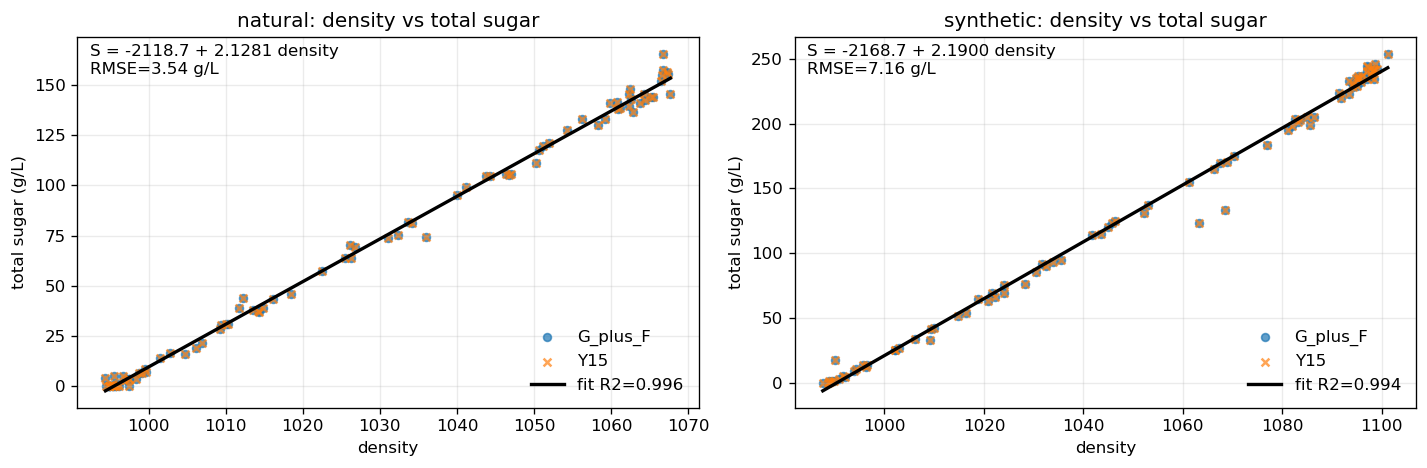

In [6]:

def plot_density_regression(points, fits):
    media = list(points["medium"].dropna().unique())
    fig, axes = plt.subplots(1, len(media), figsize=(6.0 * len(media), 4), squeeze=False)
    for ax, medium in zip(axes.ravel(), media):
        subset = points[points["medium"].eq(medium)]
        for source, marker in [("G_plus_F", "o"), ("Y15", "x")]:
            part = subset[subset["sugar_source"].eq(source)]
            ax.scatter(part["density"], part["sugar_g_l"], s=22, alpha=0.7, label=source, marker=marker)
        fit = fits[(fits["group"].eq(medium)) & (fits["source"].eq("G_plus_F"))]
        if not fit.empty:
            row = fit.iloc[0]
            x = np.linspace(subset["density"].min(), subset["density"].max(), 100)
            y = row["intercept"] + row["slope"] * x
            ax.plot(x, y, color="black", lw=2, label=f"fit R2={row['r2']:.3f}")
            ax.text(0.02, 0.98, f"S = {row['intercept']:.1f} + {row['slope']:.4f} density\nRMSE={row['rmse_g_l']:.2f} g/L", transform=ax.transAxes, va="top")
        ax.set_title(f"{medium}: density vs total sugar")
        ax.set_xlabel("density")
        ax.set_ylabel("total sugar (g/L)")
        ax.legend(frameon=False)
    fig.tight_layout()
    return fig

fig = plot_density_regression(density_points, density_fit_by_medium)
fig.savefig(RESULTS_DIR / "density_sugar_regression.png", bbox_inches="tight")
plt.show()



## Batch-level trajectories and operational inputs

The next plots show the measured states and the operational inputs used by each fermentation. Temperature is treated as a measured/setpoint input. Nutrient pulses are plotted as discrete events in mg/L N.


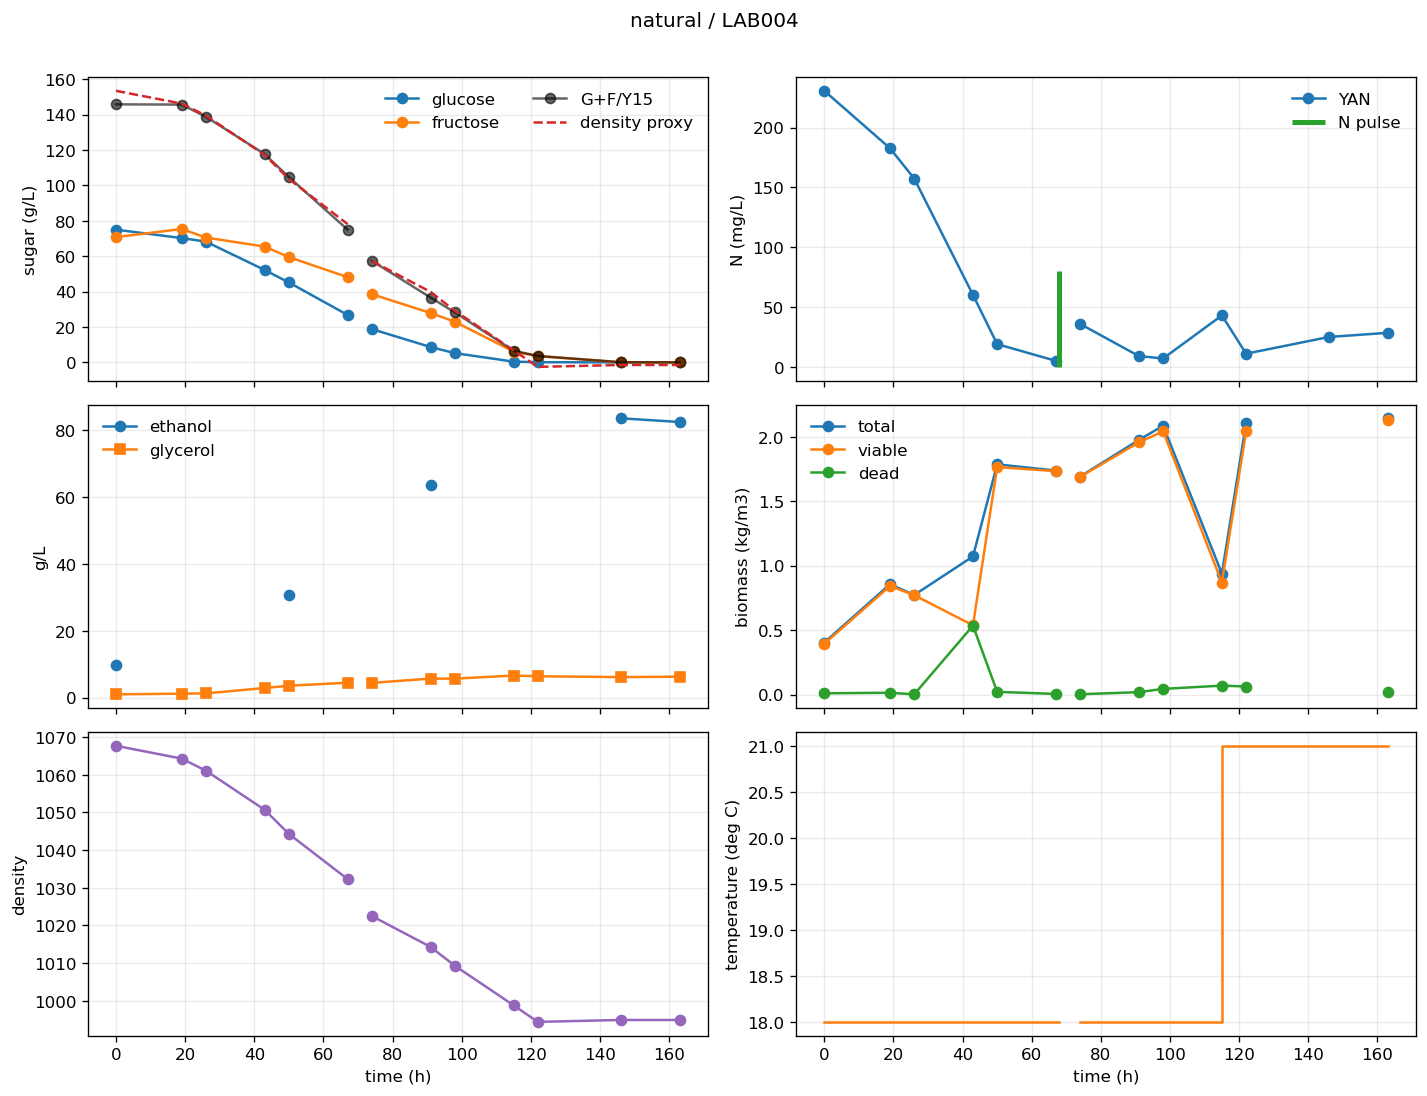

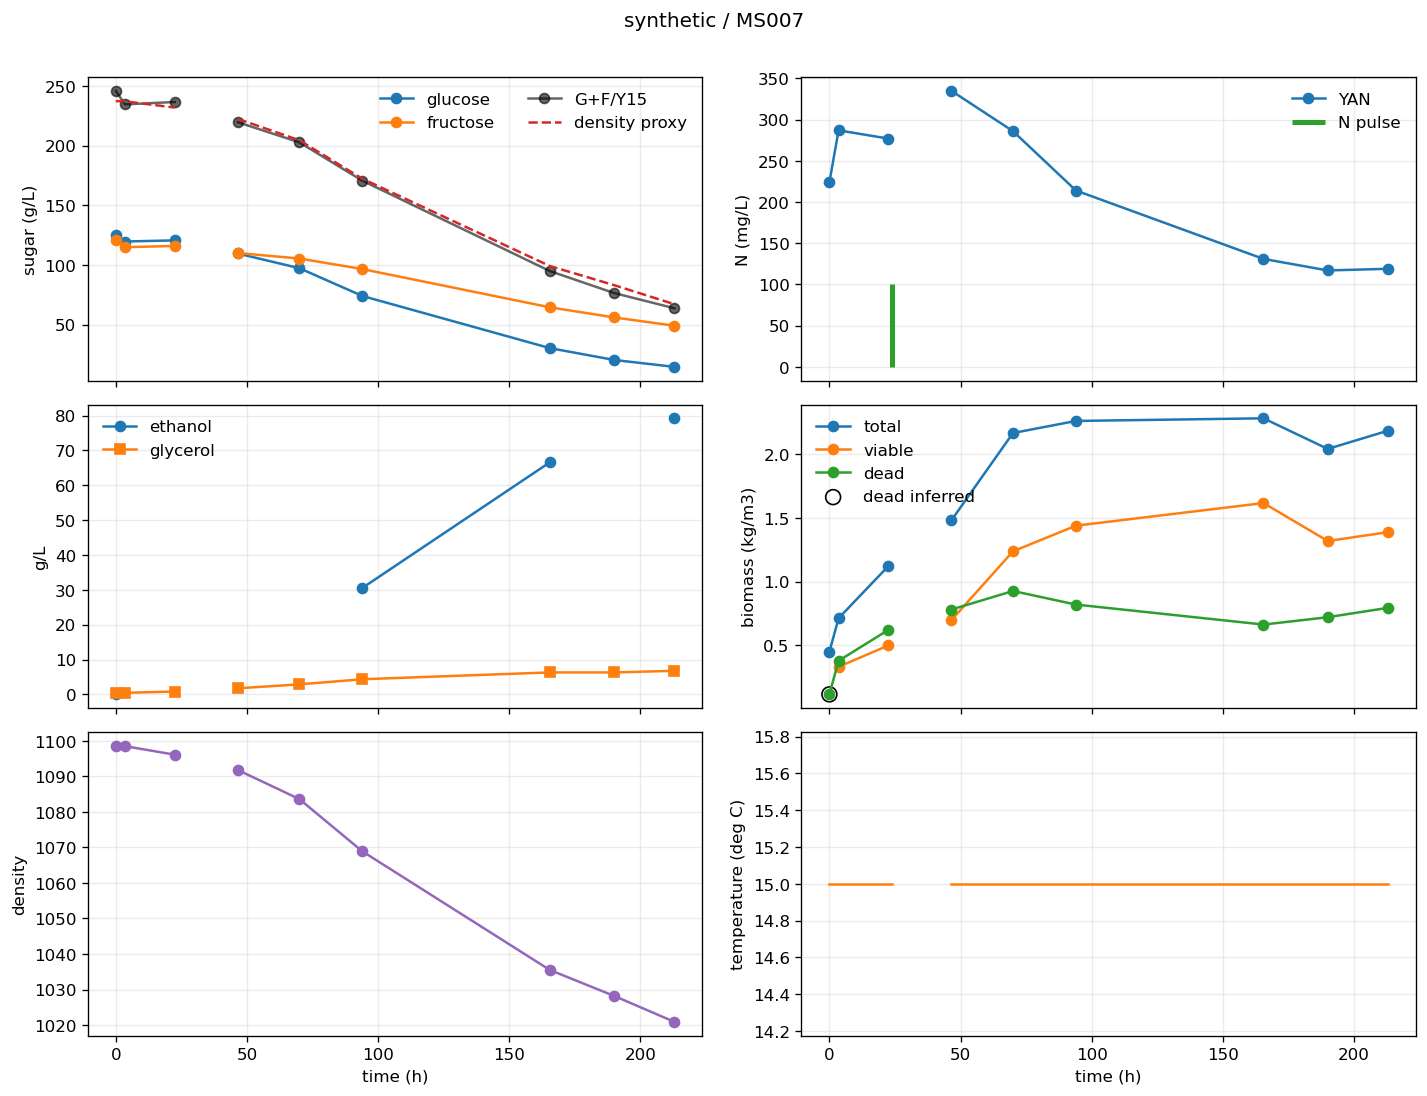

In [7]:

def plot_batch_trajectories(data, medium, batch):
    g = data[(data["medium"].eq(medium)) & (data["batch"].eq(batch))].sort_values("time_h")
    if g.empty:
        raise ValueError(f"No data for {medium}/{batch}")

    fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
    axes = axes.ravel()
    t = g["time_h"]

    axes[0].plot(t, g["G_g_l"], "o-", label="glucose")
    axes[0].plot(t, g["F_g_l"], "o-", label="fructose")
    axes[0].plot(t, g["S_observed_g_l"], "o-", label="G+F/Y15", color="black", alpha=0.6)
    axes[0].plot(t, g["S_density_g_l"], "--", label="density proxy", color="tab:red")
    axes[0].set_ylabel("sugar (g/L)")
    axes[0].legend(frameon=False, ncol=2)

    axes[1].plot(t, g["YAN_mg_l"], "o-", label="YAN")
    pulse = g[g["N_pulse_mg_l"].fillna(0) > 0]
    if not pulse.empty:
        axes[1].vlines(pulse["time_h"], 0, pulse["N_pulse_mg_l"], color="tab:green", lw=3, label="N pulse")
    axes[1].set_ylabel("N (mg/L)")
    axes[1].legend(frameon=False)

    axes[2].plot(t, g["E_g_l"], "o-", label="ethanol")
    axes[2].plot(t, g["glycerol_g_l"], "s-", label="glycerol")
    axes[2].set_ylabel("g/L")
    axes[2].legend(frameon=False)

    axes[3].plot(t, g["X_total_kg_m3"], "o-", label="total")
    axes[3].plot(t, g["X_viable_kg_m3"], "o-", label="viable")
    axes[3].plot(t, g["X_dead_kg_m3"], "o-", label="dead")
    inferred = g[g["X_dead_inferred"]]
    if not inferred.empty:
        axes[3].scatter(inferred["time_h"], inferred["X_dead_kg_m3"], s=80, facecolors="none", edgecolors="black", label="dead inferred")
    axes[3].set_ylabel("biomass (kg/m3)")
    axes[3].legend(frameon=False)

    axes[4].plot(t, g["density"], "o-", color="tab:purple")
    axes[4].set_ylabel("density")
    axes[4].set_xlabel("time (h)")

    axes[5].step(t, g["temperature_c"], where="post", color="tab:orange")
    axes[5].set_ylabel("temperature (deg C)")
    axes[5].set_xlabel("time (h)")

    fig.suptitle(f"{medium} / {batch}", y=1.01)
    fig.tight_layout()
    return fig

example_batches = [("natural", "LAB004"), ("synthetic", "MS007")]
for medium, batch in example_batches:
    fig = plot_batch_trajectories(data, medium, batch)
    fig.savefig(RESULTS_DIR / f"batch_trajectory_{medium}_{batch}.png", bbox_inches="tight")
    plt.show()


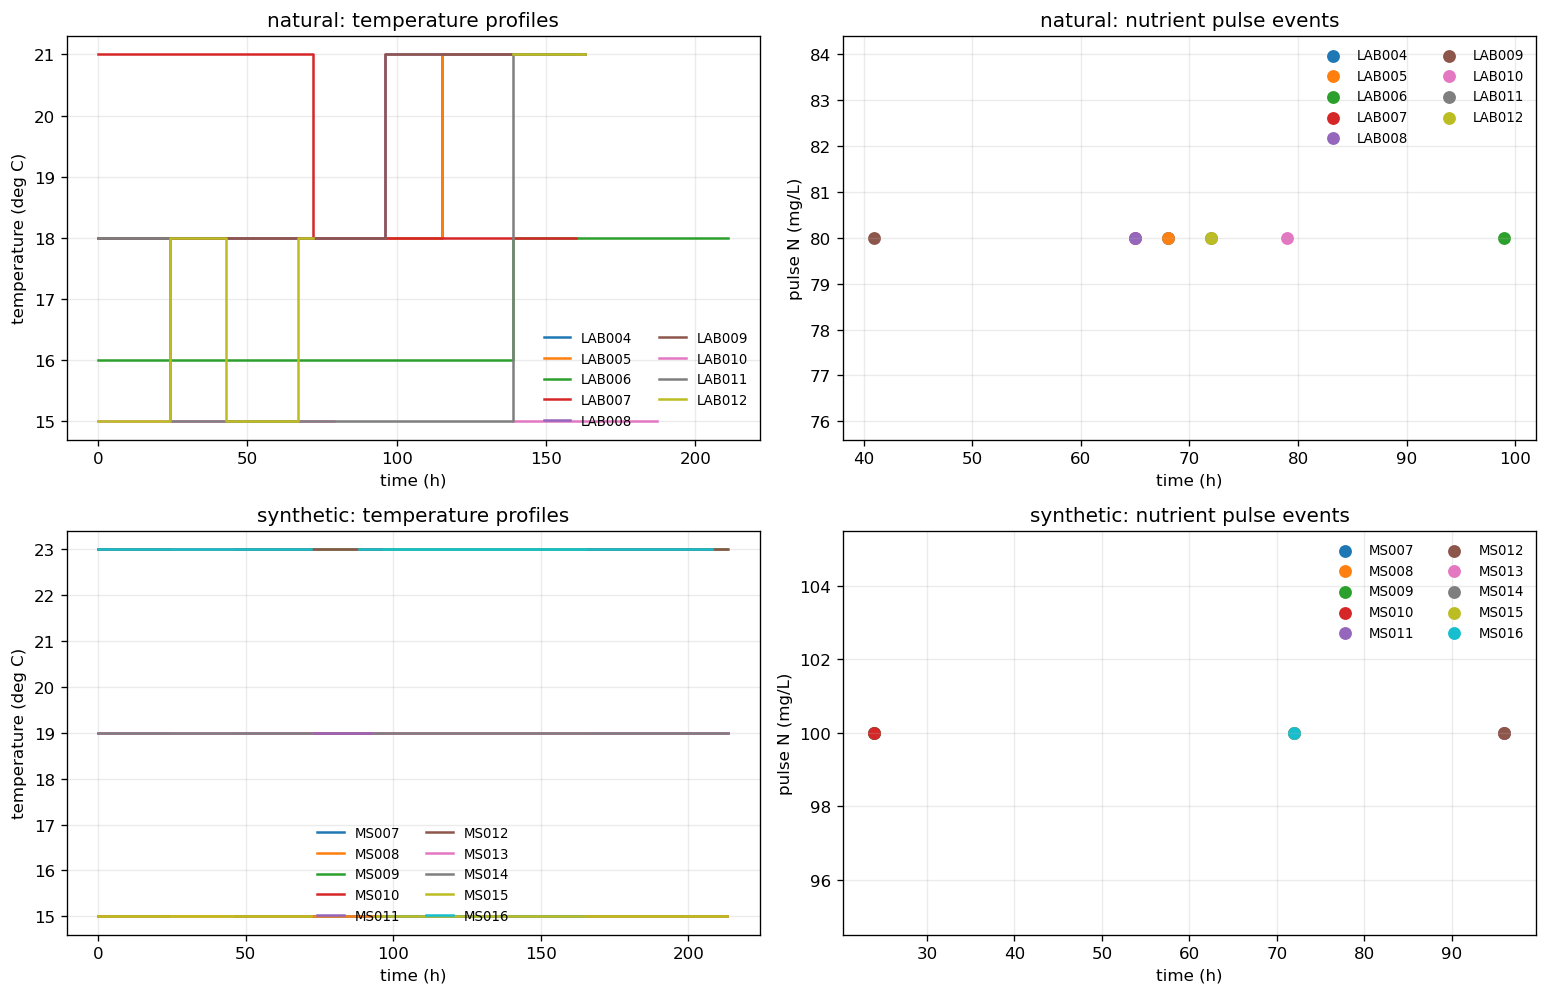

In [8]:

def plot_operational_inputs(data):
    media = list(data["medium"].dropna().unique())
    fig, axes = plt.subplots(len(media), 2, figsize=(13, 4.2 * len(media)), squeeze=False)
    for row, medium in enumerate(media):
        subset = data[data["medium"].eq(medium)]
        ax_t, ax_p = axes[row]
        for batch, g in subset.groupby("batch", sort=True):
            g = g.sort_values("time_h")
            ax_t.step(g["time_h"], g["temperature_c"], where="post", label=batch)
            pulse = g[g["N_pulse_mg_l"].fillna(0) > 0]
            if not pulse.empty:
                ax_p.scatter(pulse["time_h"], pulse["N_pulse_mg_l"], label=batch, s=45)
        ax_t.set_title(f"{medium}: temperature profiles")
        ax_t.set_xlabel("time (h)")
        ax_t.set_ylabel("temperature (deg C)")
        ax_t.legend(frameon=False, ncol=2, fontsize=8)
        ax_p.set_title(f"{medium}: nutrient pulse events")
        ax_p.set_xlabel("time (h)")
        ax_p.set_ylabel("pulse N (mg/L)")
        ax_p.legend(frameon=False, ncol=2, fontsize=8)
    fig.tight_layout()
    return fig

fig = plot_operational_inputs(data)
fig.savefig(RESULTS_DIR / "operational_inputs_by_medium.png", bbox_inches="tight")
plt.show()



## Baseline simulation with the current fermentation model

This section converts one new batch into the `FermentationBatch` object expected by the existing Pyomo/DAE notebook model. It uses the current reduced parameter file when available.

Important interpretation: this is a smoke test and baseline simulation. It is expected to show mismatch before recalibration, because the new loader uses 30 pg/cell and the previous calibration was built on the older data convention and still needs to be refit on this dataset.


In [9]:

RUN_BASELINE_SIMULATION = True
SIM_MEDIUM = "natural"
SIM_BATCH = "LAB004"

if RUN_BASELINE_SIMULATION:
    from run_fit_strategy_analysis import load_notebook_context, series_to_theta

    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        ns = load_notebook_context()
    context_log = buffer.getvalue().splitlines()
    print("Notebook model context loaded.")
    print("Context log excerpt:")
    print("\n".join(context_log[:8]))

    loader.patch_notebook_measurement_error(ns)
    notebook_batch = loader.make_notebook_batch(ns, data, SIM_MEDIUM, SIM_BATCH)

    theta = ns["_theta_for_batch"](notebook_batch, ns["DEFAULT_THETA"])
    theta_path = FERMENTATION_DIR / "results" / "identifiability_reduction" / "theta_final_identifiable.csv"
    if theta_path.exists():
        theta.update(series_to_theta(pd.read_csv(theta_path, index_col=0).iloc[:, 0]))
    theta, theta_adjustments = ns["clip_theta_to_bounds"](theta)

    model, solve_results, sim = ns["simulate_batch"](notebook_batch, theta_initial=theta, tee=False)
    sim = sim.reset_index().rename(columns={"index": "time_h", "t": "time_h"})
    if "time_h" not in sim.columns:
        sim = sim.rename(columns={sim.columns[0]: "time_h"})

    simulation_status = pd.Series(
        {
            "medium": SIM_MEDIUM,
            "batch": SIM_BATCH,
            "solver_status": str(solve_results.solver.status),
            "termination_condition": str(solve_results.solver.termination_condition),
            "n_time_points": len(sim),
        }
    )
    display(simulation_status)
    display(pd.Series(notebook_batch.initials, name="model_initials"))
    display(pd.Series({name: theta[name] for name in ["mu0", "qN", "betaG0", "betaF0", "qEG", "qEF", "iG"]}, name="theta_used"))
else:
    sim = pd.DataFrame()


Notebook model context loaded.
Context log excerpt:
IDAES Python package available: True
IDAES bin: C:\Users\ctorrealba\AppData\Local\idaes\bin
Ipopt executable: C:\Users\ctorrealba\AppData\Local\idaes\bin\ipopt.EXE
k_aug executable: C:\Users\ctorrealba\AppData\Local\idaes\bin\k_aug.EXE
dot_sens executable: C:\Users\ctorrealba\AppData\Local\idaes\bin\dot_sens.EXE
Ipopt linear solver: None
Removed solver LD_LIBRARY_PATH entries: []
Solver thread count: 1


medium                   natural
batch                     LAB004
solver_status                 ok
termination_condition    optimal
n_time_points                 61
dtype: object

X     0.393900
N     0.230760
G    75.040000
F    70.810000
E     9.707652
Name: model_initials, dtype: float64

mu0       0.156830
qN        0.013415
betaG0    0.395040
betaF0    0.283496
qEG       0.513865
qEF       0.502258
iG        0.018858
Name: theta_used, dtype: float64

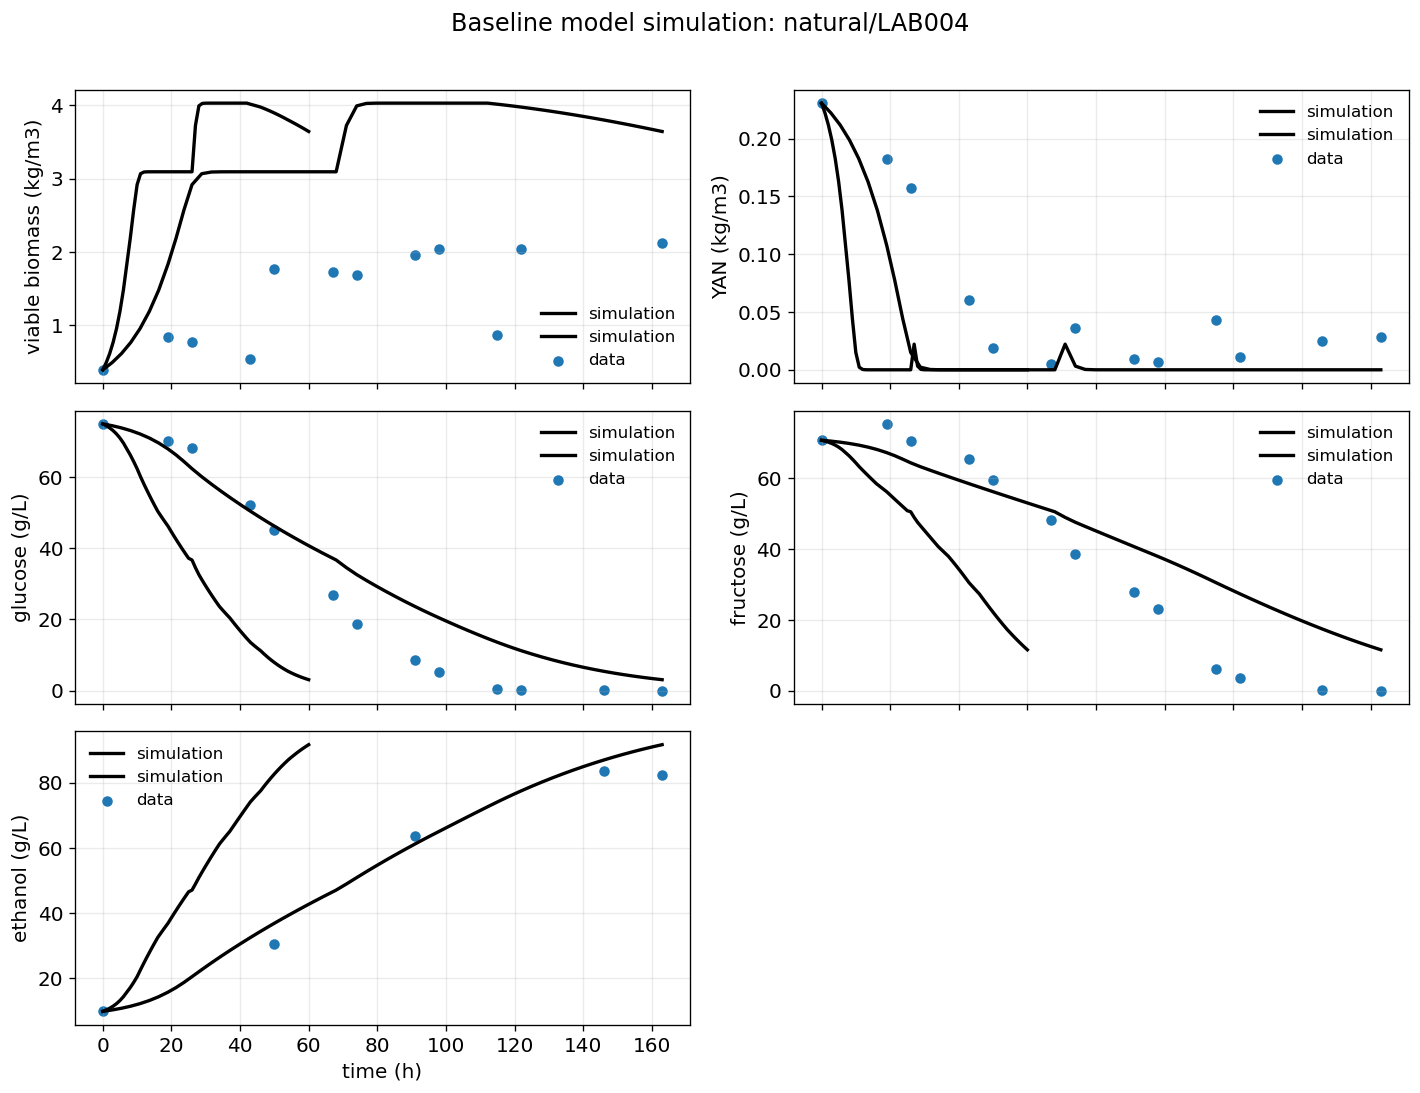

In [10]:

def plot_simulation_overlay(data, sim, medium, batch):
    g = data[(data["medium"].eq(medium)) & (data["batch"].eq(batch))].sort_values("time_h")
    fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
    axes = axes.ravel()
    mapping = [
        ("X", "X_viable_kg_m3", "viable biomass (kg/m3)"),
        ("N", "N_kg_m3", "YAN (kg/m3)"),
        ("G", "G_g_l", "glucose (g/L)"),
        ("F", "F_g_l", "fructose (g/L)"),
        ("E", "E_g_l", "ethanol (g/L)"),
    ]
    for ax, (sim_col, obs_col, label) in zip(axes, mapping):
        ax.plot(sim["time_h"], sim[sim_col], "-", color="black", label="simulation")
        ax.scatter(g["time_h"], g[obs_col], s=28, label="data")
        ax.set_ylabel(label)
        ax.legend(frameon=False)
    axes[-1].axis("off")
    axes[-2].set_xlabel("time (h)")
    fig.suptitle(f"Baseline model simulation: {medium}/{batch}", y=1.01)
    fig.tight_layout()
    return fig

if RUN_BASELINE_SIMULATION and not sim.empty:
    fig = plot_simulation_overlay(data, sim, SIM_MEDIUM, SIM_BATCH)
    fig.savefig(RESULTS_DIR / f"baseline_simulation_overlay_{SIM_MEDIUM}_{SIM_BATCH}.png", bbox_inches="tight")
    plt.show()



## Optional: run baseline simulations for all batches

Keep this disabled for normal data-review runs. It is useful only as a solver smoke test before calibration.


In [11]:

RUN_ALL_BASELINE_SIMULATIONS = False

if RUN_ALL_BASELINE_SIMULATIONS:
    rows = []
    for medium, batch in summary[["medium", "batch"]].itertuples(index=False):
        try:
            b = loader.make_notebook_batch(ns, data, medium, batch)
            theta_i = ns["_theta_for_batch"](b, ns["DEFAULT_THETA"])
            theta_i.update({name: theta[name] for name in theta if name in theta_i})
            theta_i, _ = ns["clip_theta_to_bounds"](theta_i)
            _, res_i, sim_i = ns["simulate_batch"](b, theta_initial=theta_i, tee=False)
            rows.append({"medium": medium, "batch": batch, "status": str(res_i.solver.status), "termination": str(res_i.solver.termination_condition), "n_sim": len(sim_i)})
        except Exception as err:
            rows.append({"medium": medium, "batch": batch, "status": "failed", "termination": repr(err), "n_sim": 0})
    all_sim_status = pd.DataFrame(rows)
    all_sim_status.to_csv(RESULTS_DIR / "baseline_simulation_all_status.csv", index=False)
    display(all_sim_status)



## Outputs generated

The notebook writes the following reusable files under `fermentation_model/results/new_must_data_loading/`:

- `new_must_normalized_long.csv`: one standardized long table for natural and synthetic musts.
- `new_must_batch_summary.csv`: per-batch coverage and initial/final values.
- `density_sugar_regression_points.csv`: paired density/sugar points used for fitting.
- `density_sugar_fit_by_medium.csv`: linear density-to-sugar parameters by medium.
- `density_sugar_fit_pooled.csv`: pooled linear density-to-sugar parameters.
- PNG figures for the density fit, operational inputs, example trajectories, and baseline simulation overlay.
